# Train an AI to Read Chest X-Rays

**What you're building:** A deep learning model that looks at a chest X-ray and predicts which lung conditions are present.

**What you need:** Just this notebook and a free Google Colab account with GPU enabled.

**The dataset:** 112,120 real patient chest X-rays from the NIH Clinical Center, labeled with 14 different lung conditions. This exact dataset has been used in hundreds of published medical AI papers.

**The model:** DenseNet-121, a pretrained image recognition model that you'll retrain to read X-rays instead of everyday photos.

**Time to complete:** About 2-3 hours including training time.

---

**Before you start:** Make sure GPU is enabled.
1. Click **Runtime** in the top menu
2. Click **Change runtime type**
3. Select **T4 GPU**
4. Click **Save**

Without GPU, training will take hours instead of minutes.

## Step 1: Install and Import Everything You Need

These are the tools you'll use throughout this notebook:

- **PyTorch** and **torchvision**: The deep learning framework. PyTorch handles the math behind training neural networks. Torchvision provides pretrained models and image processing tools.
- **pandas**: For reading and working with the labels spreadsheet.
- **scikit-learn**: For calculating how well your model performs (accuracy, ROC-AUC, etc.)
- **matplotlib**: For creating charts and visualizing results.
- **Pillow (PIL)**: For loading and processing images.
- **gdown**: For downloading files from Google Drive.

In [1]:
# Install gdown for downloading dataset files
!pip install -q gdown

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: GPU not detected. Go to Runtime > Change runtime type > T4 GPU')

Using device: cuda
GPU: Tesla T4


## Step 2: Get the Dataset

### What is the NIH ChestX-ray14 dataset?

The NIH Clinical Center released 112,120 frontal-view chest X-ray images from 30,805 patients. Every image is labeled with one or more of 14 lung conditions, or "No Finding" if the X-ray looks normal.

The labels were extracted from radiology reports using natural language processing. This means a computer read the doctor's written report and figured out which conditions were mentioned.

### The 14 conditions:

| Condition | What it means |
|-----------|--------------|
| Atelectasis | Part of the lung has collapsed |
| Cardiomegaly | The heart appears enlarged |
| Consolidation | Part of the lung is filled with fluid or tissue |
| Edema | Fluid buildup in the lungs |
| Effusion | Fluid between the lung and chest wall |
| Emphysema | Air sacs in the lungs are damaged |
| Fibrosis | Scarring in the lungs |
| Hernia | An organ pushes through the chest wall |
| Infiltration | Unusual substance in the lung tissue |
| Mass | A large growth or lump |
| Nodule | A small round growth |
| Pleural_Thickening | The lining around the lungs is thicker than normal |
| Pneumonia | Infection causing inflammation in the lungs |
| Pneumothorax | Air leaking between the lung and chest wall |

### Why not the full dataset?

The full dataset is about 45GB. That's too large to download in a Colab session. Instead, we'll use a curated sample of about 5,000 images, which is enough to train a solid model and learn the entire process. The methodology is identical whether you use 5,000 or 112,000 images.

### Downloading the data

We need two things:
1. **The labels file** (Data_Entry_2017.csv) - tells us which conditions each X-ray has
2. **A batch of X-ray images** - the actual images to train on

The code below downloads a sample of the dataset. If you have a Kaggle account, you can also download the full dataset from: https://www.kaggle.com/datasets/nih-chest-xrays/data

### Setting up Kaggle

1. Go to kaggle.com/settings
2. Under "API", click "Create New Token" - this downloads a kaggle.json file
3. Open the file and copy your username and key
4. In Google Colab, click the 🔑 key icon in the left sidebar
5. Add a secret named KAGGLE_USERNAME and paste your username
6. Add a secret named KAGGLE_KEY and paste your key
7. Toggle "Notebook access" on for both

In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [3]:
# Create directories
os.makedirs('data/images', exist_ok=True)

# Download the labels file
# This CSV contains labels for all 112,120 images
!pip install -q kaggle
!kaggle datasets download -f Data_Entry_2017.csv nih-chest-xrays/data -p data/ --quiet
!unzip -o -q data/Data_Entry_2017.csv.zip -d data/

# Check if labels downloaded successfully
if os.path.exists('data/Data_Entry_2017.csv'):
    labels_df = pd.read_csv('data/Data_Entry_2017.csv')
    print(f"Labels file loaded: {len(labels_df)} entries")
    print(f"Columns: {list(labels_df.columns)}")
else:
    print("ERROR: Could not download labels file.")
    print("Manual download: Go to https://nihcc.app.box.com/v/ChestXray-NIHCC")
    print("Download Data_Entry_2017_v2020.csv and upload to data/ folder")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
Labels file loaded: 112120 entries
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


In [4]:
# Download a sample batch of X-ray images
# The NIH dataset is split into 12 batches. We'll download batch 1 (~4,999 images, ~1GB)
# This may take 5-10 minutes depending on connection speed

print("Downloading X-ray images (batch 1 of 12, about 1GB)...")
print("This will take a few minutes. Be patient.\n")

!wget -q "https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz" -O data/images_001.tar.gz 2>/dev/null

# Extract the images
!tar -xzf data/images_001.tar.gz -C data/ 2>/dev/null
!mv data/images/* data/images/ 2>/dev/null || true

# Count how many images we have
image_files = [f for f in os.listdir('data/images') if f.endswith('.png')]
print(f"Downloaded {len(image_files)} X-ray images")

# Clean up the tar file to save space
!rm -f data/images_001.tar.gz

This will take a few minutes. Be patient.

Downloaded 4999 X-ray images


## Step 3: Explore the Dataset

Before training any model, you should always look at your data first. This helps you understand what you're working with and catch any problems early.

In [5]:
# Look at the first few rows of the labels
print("First 5 rows of the labels file:\n")
print(labels_df[['Image Index', 'Finding Labels', 'Patient Age', 'Patient Gender']].head(10))
print(f"\nTotal images in full dataset: {len(labels_df)}")

First 5 rows of the labels file:

        Image Index          Finding Labels  Patient Age Patient Gender
0  00000001_000.png            Cardiomegaly           58              M
1  00000001_001.png  Cardiomegaly|Emphysema           58              M
2  00000001_002.png   Cardiomegaly|Effusion           58              M
3  00000002_000.png              No Finding           81              M
4  00000003_000.png                  Hernia           81              F
5  00000003_001.png                  Hernia           74              F
6  00000003_002.png                  Hernia           75              F
7  00000003_003.png     Hernia|Infiltration           76              F
8  00000003_004.png                  Hernia           77              F
9  00000003_005.png                  Hernia           78              F

Total images in full dataset: 112120


In [6]:
# Filter labels to only include images we actually downloaded
available_images = set(os.listdir('data/images'))
df = labels_df[labels_df['Image Index'].isin(available_images)].copy()
print(f"Images we downloaded: {len(df)}")

# Look at the distribution of conditions
# Some images have multiple conditions separated by "|"
all_findings = []
for findings in df['Finding Labels']:
    all_findings.extend(findings.split('|'))

finding_counts = Counter(all_findings)
print(f"\nCondition distribution:")
for condition, count in finding_counts.most_common():
    print(f"  {condition}: {count}")

Images we downloaded: 4999

Condition distribution:
  No Finding: 2754
  Infiltration: 830
  Effusion: 487
  Atelectasis: 460
  Nodule: 214
  Consolidation: 205
  Pneumothorax: 199
  Cardiomegaly: 196
  Fibrosis: 172
  Pleural_Thickening: 165
  Mass: 161
  Emphysema: 125
  Edema: 90
  Pneumonia: 65
  Hernia: 27


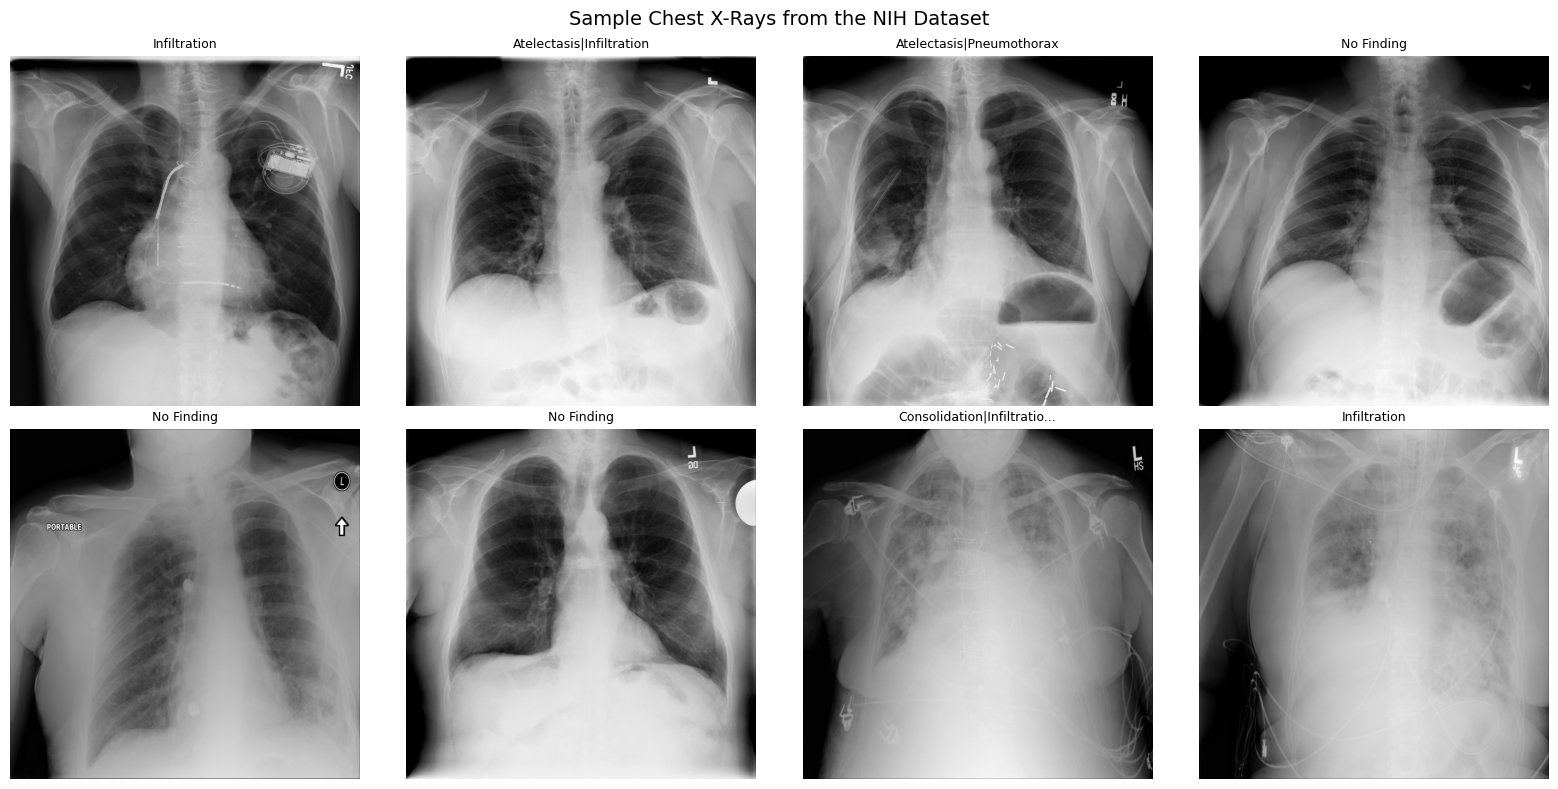

In [7]:
# Visualize some sample X-rays
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Rays from the NIH Dataset', fontsize=14)

sample_images = df.sample(8, random_state=42)
for idx, (_, row) in enumerate(sample_images.iterrows()):
    ax = axes[idx // 4][idx % 4]
    img_path = os.path.join('data/images', row['Image Index'])
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    # Truncate long labels for display
    label = row['Finding Labels']
    if len(label) > 25:
        label = label[:25] + '...'
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 4: Prepare the Data for Training

Before feeding images to DenseNet-121, we need to do a few things:

### Why resize to 224x224?
DenseNet-121 was designed to accept 224x224 pixel images. The X-rays are originally 1024x1024. Resizing them is required because the model's internal math is built around the 224x224 input size.

### Why normalize?
DenseNet-121 was originally trained on millions of everyday photos (ImageNet). Those photos were normalized using specific mean and standard deviation values. If we want to use the patterns DenseNet already learned, we need to normalize our X-rays the same way. Otherwise the pretrained weights won't work properly.

### Why convert grayscale to RGB?
Chest X-rays are grayscale (1 color channel). DenseNet-121 expects RGB images (3 color channels). We convert by copying the grayscale values into all three channels. The image looks the same, but now the model can process it.

### What is multi-label classification?
A single X-ray can show multiple conditions at once. A patient might have both pneumonia AND effusion. This means we can't just pick one label per image. Instead, we create a binary vector with 14 positions, one for each condition. If the condition is present, that position is 1. If not, it's 0. This is different from regular classification where each image gets exactly one label.

In [8]:
# Define the 14 conditions we're classifying
# These are the conditions labeled in the NIH dataset (excluding "No Finding")
CONDITIONS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

print(f"Number of conditions to classify: {len(CONDITIONS)}")
print(f"Conditions: {CONDITIONS}")

Number of conditions to classify: 14
Conditions: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [9]:
# Create the binary label matrix
# For each image, create a list of 14 zeros and ones

def encode_labels(finding_labels):
    """Convert a string like 'Atelectasis|Effusion' into a binary vector."""
    labels = np.zeros(len(CONDITIONS), dtype=np.float32)
    for i, condition in enumerate(CONDITIONS):
        if condition in finding_labels:
            labels[i] = 1.0
    return labels

# Apply to every row
df['encoded_labels'] = df['Finding Labels'].apply(encode_labels)

# Verify: show an example
example_row = df[df['Finding Labels'] != 'No Finding'].iloc[0]
print(f"Image: {example_row['Image Index']}")
print(f"Finding Labels: {example_row['Finding Labels']}")
print(f"Encoded: {example_row['encoded_labels']}")
print(f"Active conditions: {[CONDITIONS[i] for i, v in enumerate(example_row['encoded_labels']) if v == 1]}")

Image: 00000001_000.png
Finding Labels: Cardiomegaly
Encoded: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Active conditions: ['Cardiomegaly']


## Step 5: Create the Dataset and DataLoaders

PyTorch uses two concepts to feed data to models:

1. **Dataset**: Defines how to load a single image and its label. Think of it as instructions for "given image #47, here's how to find it, open it, resize it, and get its label."

2. **DataLoader**: Takes the Dataset and loads images in batches (groups of 32 at a time). It also shuffles the order during training so the model doesn't memorize patterns based on image order.

In [10]:
class ChestXrayDataset(Dataset):
    """Custom dataset for loading NIH Chest X-rays."""

    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get the image filename and labels
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_dir, row['Image Index'])
        labels = row['encoded_labels']

        # Load the image
        image = Image.open(img_path).convert('RGB')  # Convert grayscale to RGB

        # Apply transformations (resize, normalize, etc.)
        if self.transform:
            image = self.transform(image)

        return image, torch.FloatTensor(labels)

print("Dataset class created successfully")

Dataset class created successfully


In [11]:
# Define image transformations
# Training: add random augmentations to help the model generalize
train_transform = transforms.Compose([
    transforms.Resize(256),              # Resize to slightly larger than 224
    transforms.RandomCrop(224),           # Randomly crop to 224x224 (adds variation)
    transforms.RandomHorizontalFlip(),    # Randomly flip left-right (X-rays can be mirrored)
    transforms.ToTensor(),               # Convert image to PyTorch tensor (0-1 range)
    transforms.Normalize(                # Normalize with ImageNet statistics
        mean=[0.485, 0.456, 0.406],      # These exact numbers are required because
        std=[0.229, 0.224, 0.225]        # DenseNet was trained with these values
    )
])

# Validation/Test: no augmentations, just resize and normalize
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),           # Center crop instead of random crop
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined")

Transforms defined


In [12]:
# Split the data: 80% training, 10% validation, 10% test
full_dataset = ChestXrayDataset(df, 'data/images', transform=None)  # No transform yet

total = len(full_dataset)
train_size = int(0.8 * total)
val_size = int(0.1 * total)
test_size = total - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Fixed seed for reproducibility
)

# Create separate datasets with appropriate transforms
train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)
test_df = df.iloc[list(test_indices.indices)].reset_index(drop=True)

train_dataset = ChestXrayDataset(train_df, 'data/images', transform=train_transform)
val_dataset = ChestXrayDataset(val_df, 'data/images', transform=eval_transform)
test_dataset = ChestXrayDataset(test_df, 'data/images', transform=eval_transform)

print(f"Training set: {len(train_dataset)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

Training set: 3999 images
Validation set: 499 images
Test set: 501 images


In [13]:
# Create DataLoaders
# batch_size=32 means the model sees 32 images at a time before updating its weights
# num_workers=2 means 2 background processes load images while the GPU trains

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify a batch loads correctly
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")     # Should be [32, 3, 224, 224]
print(f"Labels shape: {labels.shape}")     # Should be [32, 14]
print(f"Label example: {labels[0]}")       # Binary vector for first image

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 14])
Label example: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## Step 6: Build the Model

### What is DenseNet-121?

DenseNet-121 is a convolutional neural network with 121 layers. It was created by researchers and trained on ImageNet, a dataset of over 14 million everyday photos (dogs, cars, buildings, food, etc.).

Through that training, DenseNet learned how to break down any image into meaningful patterns: edges, textures, shapes, color gradients, spatial relationships. These skills are universal. They work on photos of dogs AND on chest X-rays.

### What is transfer learning?

Instead of training a model from scratch (which would require millions of X-rays and days of training), we take DenseNet-121 with all its pretrained knowledge and just modify the final layer.

The original DenseNet-121 outputs predictions for 1,000 ImageNet categories. We replace that final layer with one that outputs predictions for our 14 chest conditions.

Then we freeze the earlier layers (keep their learned patterns intact) and only train the new final layer. This works because:
- The early layers detect basic visual features (edges, textures) that are useful for any image
- The middle layers detect more complex patterns (shapes, structures) that are also general
- Only the final layer needs to learn "these specific patterns mean pneumonia"

### Why DenseNet-121 specifically?

DenseNet-121 was used in the original CheXpert paper from Stanford and has become the standard baseline for chest X-ray classification. It achieves strong performance while being small enough to train quickly on a free GPU.

In [14]:
# Load DenseNet-121 with pretrained ImageNet weights
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Look at the original final layer
print(f"Original classifier: {model.classifier}")
print(f"It outputs {model.classifier.out_features} categories (ImageNet)")

# Replace the final layer for our 14 conditions
# DenseNet-121's classifier input size is 1024
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(CONDITIONS))

print(f"\nNew classifier: {model.classifier}")
print(f"Now outputs {len(CONDITIONS)} categories (chest conditions)")

# Move model to GPU
model = model.to(device)
print(f"\nModel loaded on {device}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 167MB/s]


Original classifier: Linear(in_features=1024, out_features=1000, bias=True)
It outputs 1000 categories (ImageNet)

New classifier: Linear(in_features=1024, out_features=14, bias=True)
Now outputs 14 categories (chest conditions)

Model loaded on cuda


In [15]:
# Freeze all layers except the classifier
# This means only the final layer will be updated during training
# Everything else keeps its ImageNet knowledge intact

for param in model.parameters():
    param.requires_grad = False  # Don't update these weights

# Unfreeze the classifier (the layer we just replaced)
for param in model.classifier.parameters():
    param.requires_grad = True  # Do update these weights

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print(f"\nYou're only training {trainable_params/total_params*100:.2f}% of the model")

Total parameters: 6,968,206
Trainable parameters: 14,350
Frozen parameters: 6,953,856

You're only training 0.21% of the model


## Step 7: Train the Model

### How training works

Training is a loop:
1. Show the model a batch of 32 X-rays
2. The model makes predictions (guesses which conditions are present)
3. Compare predictions to the real labels using a **loss function**
4. Calculate how wrong the model was
5. Adjust the model's weights slightly to be less wrong next time
6. Repeat thousands of times

### Why BCEWithLogitsLoss?

Since one X-ray can have multiple conditions (multi-label), we use **Binary Cross-Entropy Loss** (BCE). It treats each of the 14 conditions as a separate yes/no question: "Is atelectasis present? Is cardiomegaly present?" Each condition is evaluated independently.

This is different from regular classification (CrossEntropy) which forces the model to pick exactly one category.

### What is an epoch?

One epoch = the model has seen every training image exactly once. We'll train for 5 epochs initially, which means the model sees each image 5 times. With each pass, it gets slightly better at recognizing patterns.

In [16]:
# Set up training components

# Loss function: BCEWithLogitsLoss for multi-label classification
# "WithLogits" means it applies sigmoid internally, which is more numerically stable
criterion = nn.BCEWithLogitsLoss()

# Optimizer: Adam is a widely used optimizer that adapts learning rates automatically
# lr=0.001 means each weight update is small, which prevents overshooting
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Learning rate scheduler: reduces learning rate when validation loss stops improving
# This helps the model fine-tune as it gets closer to optimal performance
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)

NUM_EPOCHS = 5
print("Training setup complete")
print(f"Loss function: BCEWithLogitsLoss (for multi-label classification)")
print(f"Optimizer: Adam (learning rate = 0.001)")
print(f"Epochs: {NUM_EPOCHS}")

Training setup complete
Loss function: BCEWithLogitsLoss (for multi-label classification)
Optimizer: Adam (learning rate = 0.001)
Epochs: 5


In [17]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train the model for one epoch and return the average loss."""
    model.train()  # Set model to training mode
    running_loss = 0.0
    num_batches = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: model makes predictions
        outputs = model(images)

        # Calculate loss: how wrong were the predictions?
        loss = criterion(outputs, labels)

        # Backward pass: calculate gradients (how to adjust each weight)
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update weights

        running_loss += loss.item()
        num_batches += 1

        # Print progress every 25 batches
        if (batch_idx + 1) % 25 == 0:
            print(f"  Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    return running_loss / num_batches


def validate(model, val_loader, criterion, device):
    """Evaluate the model on the validation set."""
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    running_loss = 0.0
    all_outputs = []
    all_labels = []

    with torch.no_grad():  # Don't calculate gradients during validation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Apply sigmoid to get probabilities (0 to 1)
            probs = torch.sigmoid(outputs)
            all_outputs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_outputs = np.concatenate(all_outputs)
    all_labels = np.concatenate(all_labels)

    # Calculate ROC-AUC for conditions that have both positive and negative examples
    aucs = []
    for i, condition in enumerate(CONDITIONS):
        if len(np.unique(all_labels[:, i])) > 1:  # Need both 0s and 1s
            auc = roc_auc_score(all_labels[:, i], all_outputs[:, i])
            aucs.append(auc)

    mean_auc = np.mean(aucs) if aucs else 0.0
    avg_loss = running_loss / len(val_loader)

    return avg_loss, mean_auc

print("Training and validation functions defined")

Training and validation functions defined


In [18]:
# Train the model
print("=" * 60)
print("TRAINING STARTED")
print("=" * 60)

best_val_auc = 0.0
train_losses = []
val_losses = []
val_aucs = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 40)

    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    # Validate
    val_loss, val_auc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Mean AUC: {val_auc:.4f}")

    # Save the best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  >> New best model saved (AUC: {val_auc:.4f})")

print("\n" + "=" * 60)
print(f"Training complete. Best validation AUC: {best_val_auc:.4f}")
print("=" * 60)

TRAINING STARTED

Epoch 1/5
----------------------------------------
  Batch 25/125, Loss: 0.1501
  Batch 50/125, Loss: 0.1560
  Batch 75/125, Loss: 0.1921
  Batch 100/125, Loss: 0.2483
  Batch 125/125, Loss: 0.1511
  Train Loss: 0.1940
  Val Loss: 0.1777
  Val Mean AUC: 0.6250
  >> New best model saved (AUC: 0.6250)

Epoch 2/5
----------------------------------------
  Batch 25/125, Loss: 0.1458
  Batch 50/125, Loss: 0.1952
  Batch 75/125, Loss: 0.1703
  Batch 100/125, Loss: 0.1849
  Batch 125/125, Loss: 0.1772
  Train Loss: 0.1726
  Val Loss: 0.1694
  Val Mean AUC: 0.6821
  >> New best model saved (AUC: 0.6821)

Epoch 3/5
----------------------------------------
  Batch 25/125, Loss: 0.1929
  Batch 50/125, Loss: 0.0984
  Batch 75/125, Loss: 0.1357
  Batch 100/125, Loss: 0.1147
  Batch 125/125, Loss: 0.2005
  Train Loss: 0.1689
  Val Loss: 0.1699
  Val Mean AUC: 0.7137
  >> New best model saved (AUC: 0.7137)

Epoch 4/5
----------------------------------------
  Batch 25/125, Loss: 0.1

### Visualize Training Progress

These charts show how the model improved over time.

- **Loss** should go down (the model is making fewer mistakes)
- **AUC** should go up (the model is getting better at distinguishing conditions)

If validation loss starts going UP while training loss keeps going DOWN, that means the model is overfitting (memorizing training images instead of learning general patterns).

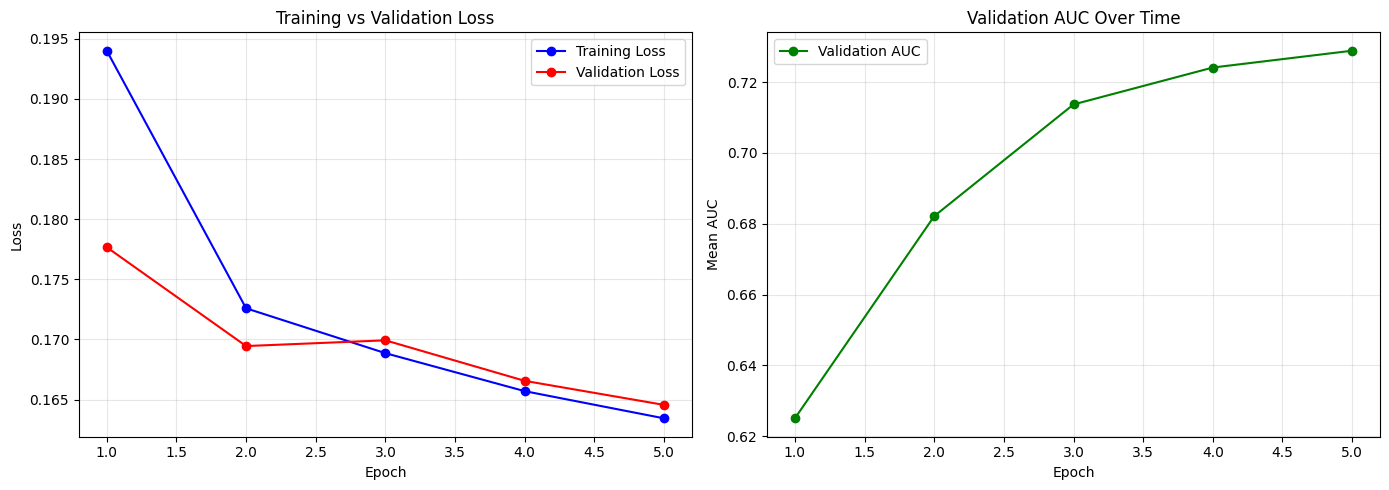

In [19]:
# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o', label='Training Loss')
ax1.plot(range(1, NUM_EPOCHS + 1), val_losses, 'r-o', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AUC plot
ax2.plot(range(1, NUM_EPOCHS + 1), val_aucs, 'g-o', label='Validation AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean AUC')
ax2.set_title('Validation AUC Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Fine-Tune the Full Model (Optional but Recommended)

So far, we only trained the final layer. The rest of DenseNet kept its ImageNet knowledge frozen. Now we'll unfreeze everything and train the entire model at a much lower learning rate.

Why a lower learning rate? Because the earlier layers already have useful knowledge. We don't want to erase it. We just want to gently adjust it to better fit X-ray patterns instead of everyday photo patterns.

Think of it like this: the initial training taught the model "these are the 14 conditions." Fine-tuning teaches it "and here are the subtle visual differences specific to X-rays that help distinguish them."

In [20]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Use a much smaller learning rate for fine-tuning
# 10x smaller than initial training
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)

FINETUNE_EPOCHS = 3
print(f"Fine-tuning all {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Learning rate: 0.0001 (10x smaller than initial training)")
print(f"Epochs: {FINETUNE_EPOCHS}")

Fine-tuning all 6,968,206 parameters
Learning rate: 0.0001 (10x smaller than initial training)
Epochs: 3


In [21]:
# Fine-tune the model
print("=" * 60)
print("FINE-TUNING STARTED")
print("=" * 60)

for epoch in range(FINETUNE_EPOCHS):
    print(f"\nFine-tune Epoch {epoch + 1}/{FINETUNE_EPOCHS}")
    print("-" * 40)

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    scheduler.step(val_loss)

    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Mean AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  >> New best model saved (AUC: {val_auc:.4f})")

print("\n" + "=" * 60)
print(f"Fine-tuning complete. Best AUC: {best_val_auc:.4f}")
print("=" * 60)

FINE-TUNING STARTED

Fine-tune Epoch 1/3
----------------------------------------
  Batch 25/125, Loss: 0.1251
  Batch 50/125, Loss: 0.1175
  Batch 75/125, Loss: 0.1184
  Batch 100/125, Loss: 0.1574
  Batch 125/125, Loss: 0.2043
  Train Loss: 0.1583
  Val Loss: 0.1568
  Val Mean AUC: 0.7697
  >> New best model saved (AUC: 0.7697)

Fine-tune Epoch 2/3
----------------------------------------
  Batch 25/125, Loss: 0.1236
  Batch 50/125, Loss: 0.1106
  Batch 75/125, Loss: 0.1603
  Batch 100/125, Loss: 0.1826
  Batch 125/125, Loss: 0.1394
  Train Loss: 0.1457
  Val Loss: 0.1526
  Val Mean AUC: 0.7896
  >> New best model saved (AUC: 0.7896)

Fine-tune Epoch 3/3
----------------------------------------
  Batch 25/125, Loss: 0.0954
  Batch 50/125, Loss: 0.1438
  Batch 75/125, Loss: 0.1194
  Batch 100/125, Loss: 0.1568
  Batch 125/125, Loss: 0.1464
  Train Loss: 0.1344
  Val Loss: 0.1528
  Val Mean AUC: 0.7833

Fine-tuning complete. Best AUC: 0.7896


## Step 9: Evaluate Your Model

Now we test the model on images it has never seen before (the test set).

### Understanding the metrics

- **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve): Measures how well the model distinguishes between positive and negative cases. Ranges from 0 to 1. A score of 0.5 means the model is guessing randomly. Above 0.8 is generally considered good. Above 0.9 is excellent.

- **Precision**: When the model says "this X-ray shows pneumonia," how often is it correct? High precision = few false alarms.

- **Recall**: Out of all X-rays that actually have pneumonia, how many did the model catch? High recall = few missed cases.

- **F1 Score**: The balance between precision and recall. Useful when you want a single number to summarize performance.

For medical applications, **recall** is especially important because missing a disease (false negative) is usually worse than a false alarm (false positive).

In [22]:
# Load the best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Get predictions on the test set
all_outputs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_outputs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_outputs = np.concatenate(all_outputs)
all_labels = np.concatenate(all_labels)

# Calculate ROC-AUC for each condition
print("ROC-AUC per condition:")
print("-" * 40)
auc_scores = {}
for i, condition in enumerate(CONDITIONS):
    if len(np.unique(all_labels[:, i])) > 1:
        auc = roc_auc_score(all_labels[:, i], all_outputs[:, i])
        auc_scores[condition] = auc
        status = "excellent" if auc > 0.9 else "good" if auc > 0.8 else "fair" if auc > 0.7 else "needs improvement"
        print(f"  {condition:25s} AUC: {auc:.4f} ({status})")
    else:
        print(f"  {condition:25s} Not enough positive cases to evaluate")

if auc_scores:
    print(f"\n  {'Mean AUC':25s} {np.mean(list(auc_scores.values())):.4f}")

ROC-AUC per condition:
----------------------------------------
  Atelectasis               AUC: 0.7293 (fair)
  Cardiomegaly              AUC: 0.8568 (good)
  Consolidation             AUC: 0.8350 (good)
  Edema                     AUC: 0.9729 (excellent)
  Effusion                  AUC: 0.8485 (good)
  Emphysema                 AUC: 0.7448 (fair)
  Fibrosis                  AUC: 0.6898 (needs improvement)
  Hernia                    AUC: 0.9880 (excellent)
  Infiltration              AUC: 0.7096 (fair)
  Mass                      AUC: 0.7638 (fair)
  Nodule                    AUC: 0.6871 (needs improvement)
  Pleural_Thickening        AUC: 0.8130 (good)
  Pneumonia                 AUC: 0.6768 (needs improvement)
  Pneumothorax              AUC: 0.8636 (good)

  Mean AUC                  0.7985


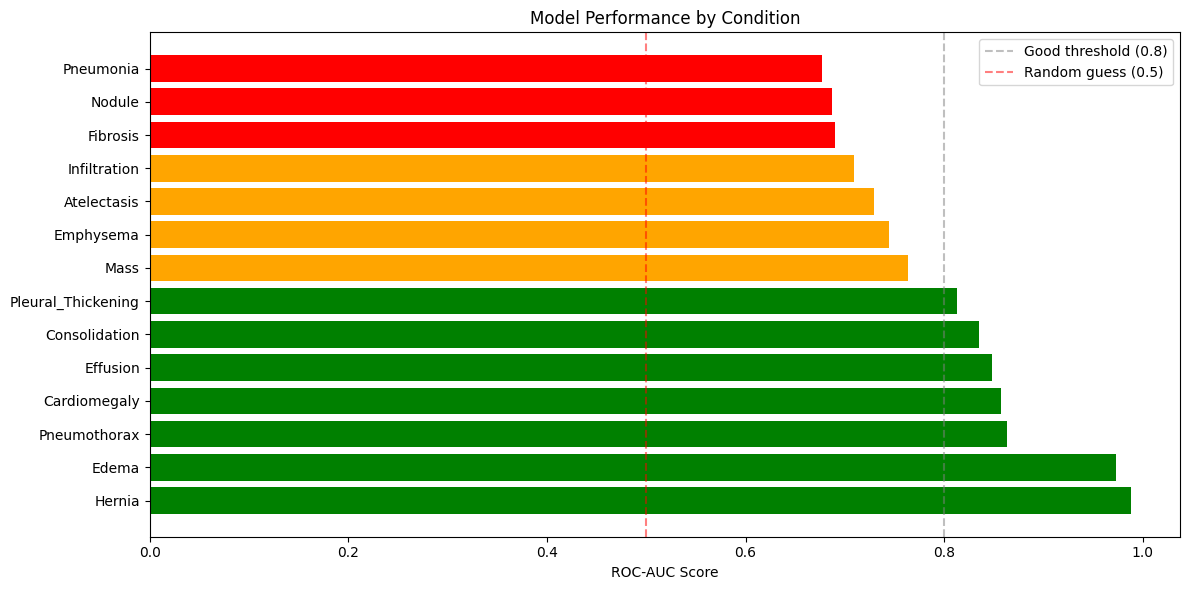

In [23]:
# Visualize ROC-AUC scores as a bar chart
if auc_scores:
    conditions = list(auc_scores.keys())
    scores = list(auc_scores.values())

    # Sort by AUC score
    sorted_pairs = sorted(zip(conditions, scores), key=lambda x: x[1], reverse=True)
    conditions, scores = zip(*sorted_pairs)

    # Color bars based on performance
    colors = ['green' if s > 0.8 else 'orange' if s > 0.7 else 'red' for s in scores]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(conditions)), scores, color=colors)
    plt.yticks(range(len(conditions)), conditions)
    plt.xlabel('ROC-AUC Score')
    plt.title('Model Performance by Condition')
    plt.axvline(x=0.8, color='gray', linestyle='--', alpha=0.5, label='Good threshold (0.8)')
    plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess (0.5)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [24]:
# Generate predictions using 0.5 threshold
predictions = (all_outputs > 0.5).astype(int)

# Classification report for conditions with enough samples
print("Detailed Classification Report:")
print("=" * 60)
for i, condition in enumerate(CONDITIONS):
    pos_count = int(all_labels[:, i].sum())
    pred_count = int(predictions[:, i].sum())
    if pos_count > 0:
        from sklearn.metrics import precision_score, recall_score, f1_score
        precision = precision_score(all_labels[:, i], predictions[:, i], zero_division=0)
        recall = recall_score(all_labels[:, i], predictions[:, i], zero_division=0)
        f1 = f1_score(all_labels[:, i], predictions[:, i], zero_division=0)
        print(f"  {condition:25s} Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}  (True positives: {pos_count})")

Detailed Classification Report:
  Atelectasis               Precision: 0.143  Recall: 0.018  F1: 0.032  (True positives: 56)
  Cardiomegaly              Precision: 1.000  Recall: 0.038  F1: 0.074  (True positives: 26)
  Consolidation             Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 20)
  Edema                     Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 8)
  Effusion                  Precision: 0.667  Recall: 0.218  F1: 0.329  (True positives: 55)
  Emphysema                 Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 18)
  Fibrosis                  Precision: 1.000  Recall: 0.062  F1: 0.118  (True positives: 16)
  Hernia                    Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 2)
  Infiltration              Precision: 0.667  Recall: 0.077  F1: 0.138  (True positives: 78)
  Mass                      Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 15)
  Nodule                    Precision: 0

## Step 10: Test on Individual X-Rays

Now let's see the model in action on individual images. This is what your model would do if you deployed it as an app: take in one X-ray and predict what conditions might be present.

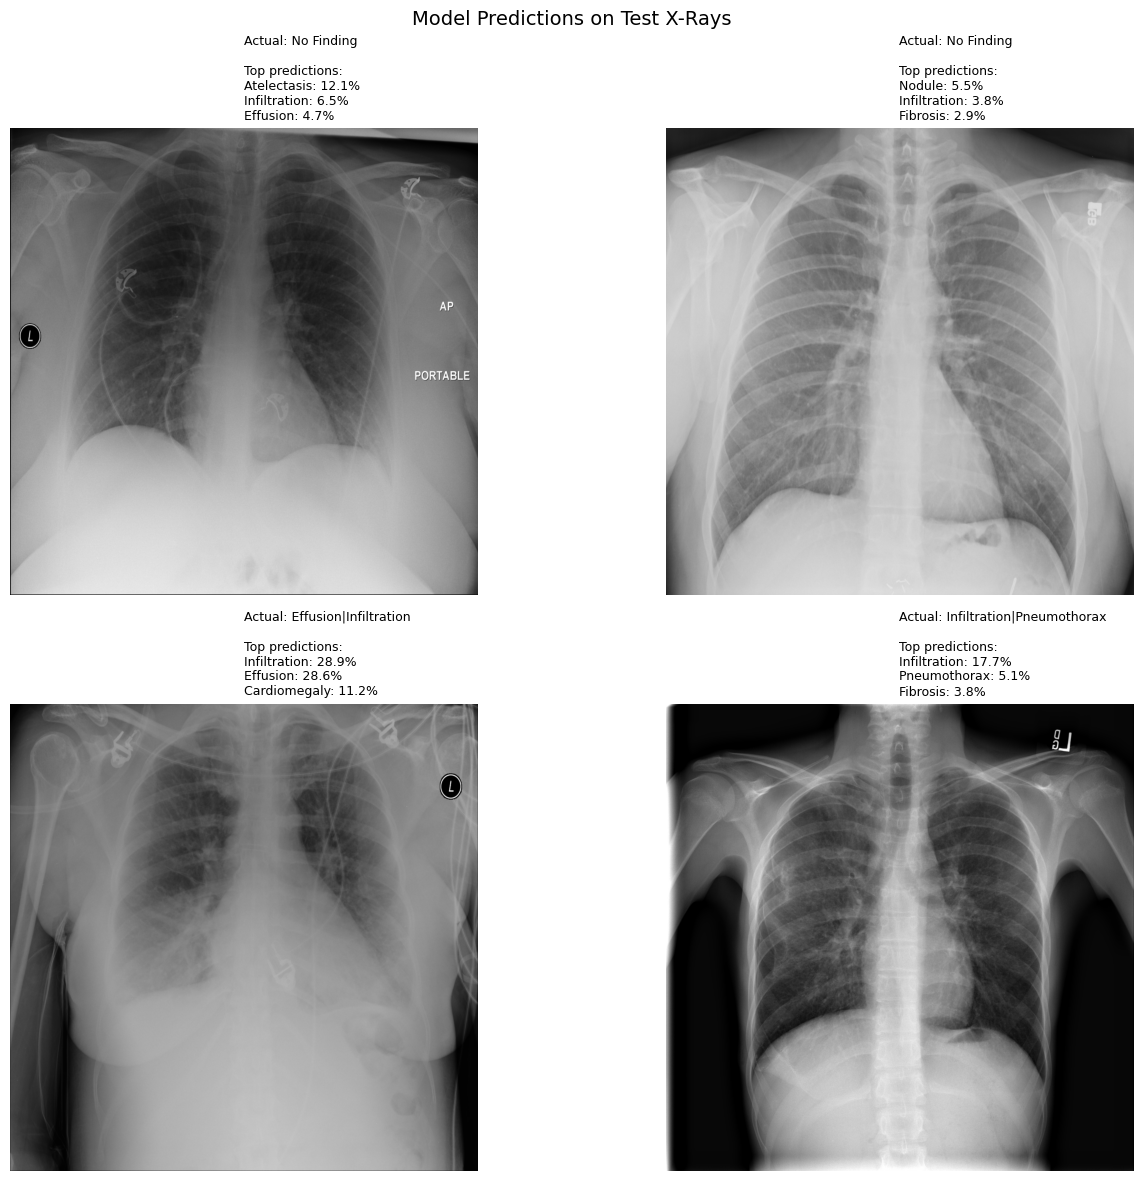

In [25]:
def predict_single_image(model, image_path, transform, device):
    """Load a single X-ray image and predict conditions."""
    # Load and transform the image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Get predictions
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.sigmoid(output).cpu().numpy()[0]

    return image, probabilities


# Pick 4 random test images and show predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sample_test = test_df.sample(4, random_state=123)

for idx, (_, row) in enumerate(sample_test.iterrows()):
    ax = axes[idx // 2][idx % 2]
    img_path = os.path.join('data/images', row['Image Index'])

    image, probs = predict_single_image(model, img_path, eval_transform, device)

    # Display the X-ray
    ax.imshow(image, cmap='gray')

    # Show top 3 predictions
    top_indices = np.argsort(probs)[::-1][:3]
    pred_text = "\n".join([f"{CONDITIONS[i]}: {probs[i]:.1%}" for i in top_indices])
    actual = row['Finding Labels']

    ax.set_title(f"Actual: {actual}\n\nTop predictions:\n{pred_text}", fontsize=9, ha='left')
    ax.axis('off')

plt.suptitle('Model Predictions on Test X-Rays', fontsize=14)
plt.tight_layout()
plt.show()

## What to Do Next

You now have a working chest X-ray classifier. Here are several directions you can take this:

### Turn it into research
- **Bias analysis**: Test if your model performs differently across age groups or genders. Split the test set by `Patient Age` and `Patient Gender` columns and compare AUC scores.
- **Compare architectures**: Train the same dataset with ResNet-50 or EfficientNet-B0 and compare performance. Which model does better on which conditions? Why?
- **Improve on specific conditions**: Some conditions are harder than others. Pick the worst-performing one and try to improve it with techniques like class weighting, data augmentation, or focal loss.

### Build a web app
- Use **Streamlit** to create a web app where anyone can upload an X-ray and get predictions
- Deploy it for free on Streamlit Cloud
- Now you have a deployed AI product, not just a notebook

### Visualize what the model sees
- Use **Grad-CAM** (Gradient-weighted Class Activation Mapping) to generate heatmaps showing which parts of the X-ray the model focuses on for each prediction
- This is what medical AI researchers publish in papers: the model highlights the exact region of the lung that triggered its prediction

### Submit your work
- **Science fairs**: This project is strong enough for regional and potentially state-level science fairs
- **Regeneron STS**: If you add a research angle (bias analysis, architecture comparison), the deadline is November
- **Journals**: Journal of Emerging Investigators and Journal of Student Research accept this type of computational work

### Scale up
- Download the full 112,000 image dataset for better performance
- Use **CheXpert** (224,316 images from Stanford) as an additional training set
- Combine multiple datasets and test how well the model generalizes across different hospitals